# Dimensions Paper Metrics — Validation & Visualization

Every output of `Dimensions/notebook/*.ipynb` in one place: what is defined, what the
distributions look like, whether the windowed metrics behave as their definitions require, and
whether the patterns the OpenAlex pipeline shows survive on the **Dimensions June 2025** index
(155.5 M publications, 2.14 B reference edges). The twin of `paper_validation.ipynb`
and `case_law_validation.ipynb`; the section numbering follows the latter so the three
families can be read side by side.

## What is different about this index (see `Dimensions/Readme.txt` §4)
* fields are **ANZSRC FoR 2020 divisions** (23), not OpenAlex's 26 topic fields — `FoS_rep` is the
  first division listed, there is no score;
* a "journal" is `source_titles.type == 'journal'`;
* the patent→paper channel is Dimensions' own patent index (`pat2p`, `pat2p_us`), not PCS;
* `doc_class` (RESEARCH_ARTICLE, REVIEW_ARTICLE, …) exists here and not in OpenAlex.

## Guarded sections
The Dimensions chain writes its outputs in dependency order (`jobs/Dimensions/submit_dimensions.sh`).
A section whose input is not on disk yet prints one line and moves on; re-run the notebook when
the chain has finished and the section fills in. `preflight()` in cell 1 lists what is present.

## Sections
1. Coverage — how many publications have each metric defined
2. The corpus in time — publication years, document types
3. Forward citations — distributions and windowed monotonicity
4. Mean citations by year — and the truncation it exposes
5. Citation age profile (from the trend file)
6. Disruption — CD distribution and the ni / nj / nk composition
7. F / E / G — the citing profile
8. Hit percentile — zero inflation and cohort sizes
9. By field — does the FoR division behave?
10. Cross-metric correlations
11. Sleeping beauties
12. Atypicality — Z-score CDF and the 2×2 hit probability
13. Authors — team size, resolved authors, countries
14. Dimensions against OpenAlex — the same metrics on the other index

In [1]:
import os, sys, gc, json
import numpy as np, pandas as pd, duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline
plt.rcParams['figure.dpi'] = 110

sys.path.insert(0, '/project/jevans/Dawoon/Science of Science/validation')
import val_common as V
V.init('dimension_validation')
D = V.dim
META, CIT, AU = D('paper_metadata.parquet'), D('paper_citation.parquet'), D('paper_author.parquet')
DIS, SB, HIT, TRD = D('paper_disruption.parquet'), D('paper_sb.parquet'), D('paper_hit_probability.parquet'), D('paper_citation_trend.parquet')
ZS, ZP = D('paper_z_score.parquet'), D('z_score_pair.parquet')
HAS = {k: os.path.exists(p) for k, p in dict(meta=META, cit=CIT, au=AU, dis=DIS, sb=SB, hit=HIT, trd=TRD, zs=ZS).items()}

# Slots 1-4 of the reference categorical theme, validated as a set on the light surface.
BLUE, ORANGE, AQUA, VIOLET = '#2a78d6', '#eb6834', '#1baf7a', '#4a3aa7'
INK, MUTED, GRID, SURFACE = '#0b0b0b', '#52514e', '#e6e5e1', '#fcfcfb'
SNAP = 2025                     # last citing year in the dump
YEAR_MIN = 1900                 # the corpus is thin before this; every figure starts here

def style(ax, xlab=None, ylab=None, title=None):
    ax.set_facecolor(SURFACE); ax.grid(axis='y', color=GRID, lw=.8, zorder=0)
    ax.set_axisbelow(True); ax.tick_params(colors=MUTED, length=3)
    for sp in ax.spines.values():
        sp.set_color(GRID)
    if xlab: ax.set_xlabel(xlab, color=MUTED)
    if ylab: ax.set_ylabel(ylab, color=MUTED)
    if title: ax.set_title(title, color=INK, loc='left', pad=8)
    return ax

def skip(section, what):
    print(f'[{section}] {what} is not on disk yet -- the Dimensions chain has not written it; re-run when it has.')

con = duckdb.connect()
con.execute("SET memory_limit='160GB'")
con.execute(f"SET temp_directory='{V.TMP}'")
con.execute('SET preserve_insertion_order=false')
ok = V.preflight('dimension_validation')
N_CORPUS = con.execute(f"SELECT count(*) FROM read_parquet('{META}')").fetchone()[0]
print(f'\ncorpus: {N_CORPUS:,} publications in paper_metadata')

[val] dimension_validation  ->  /project/jevans/Dawoon/Science of Science/validation/Figures/dimension_validation_<section>.{jpg,pdf}  @ 600 dpi
  dimension_validationMISSING 1
      Dimensions/output/paper_z_score.parquet  <- not present

corpus: 155,507,994 publications in paper_metadata


## 1. Coverage — how many publications have each metric defined

`defined` is not `present`. A publication with no citers has `CD = NaN` by construction; one
never cited is absent from `paper_sb` but present in `paper_citation` with a zero. Both are
correct, and conflating them would silently make every downstream mean conditional on being cited.

In [2]:
%%time
rows = [dict(file='paper_metadata', rows=N_CORPUS, key_defined=con.execute(f"SELECT count(year) FROM read_parquet('{META}')").fetchone()[0], key_col='year')]
rows.append(dict(file='paper_citation', **dict(zip(('rows', 'key_defined'), con.execute(f"SELECT count(*), count(*) FILTER (WHERE C_all > 0) FROM read_parquet('{CIT}')").fetchone())), key_col='C_all > 0'))
rows.append(dict(file='paper_author', **dict(zip(('rows', 'key_defined'), con.execute(f"SELECT count(*), count(author_list) FROM read_parquet('{AU}')").fetchone())), key_col='author_list not null (>= 1 resolved author)'))
if HAS['dis']:
    rows.append(dict(file='paper_disruption', **dict(zip(('rows', 'key_defined'), con.execute(f"SELECT count(*), count(CD_all) FROM read_parquet('{DIS}')").fetchone())), key_col='CD_all not null'))
if HAS['hit']:
    rows.append(dict(file='paper_hit_probability', **dict(zip(('rows', 'key_defined'), con.execute(f"SELECT count(*), count(pctl_call) FROM read_parquet('{HIT}')").fetchone())), key_col='pctl_call not null'))
if HAS['sb']:
    rows.append(dict(file='paper_sb', **dict(zip(('rows', 'key_defined'), con.execute(f"SELECT count(*), count(*) FILTER (WHERE n_cite >= 5) FROM read_parquet('{SB}')").fetchone())), key_col='n_cite >= 5'))
if HAS['trd']:
    rows.append(dict(file='paper_citation_trend', **dict(zip(('rows', 'key_defined'), con.execute(f"SELECT count(*), count(DISTINCT paper_id) FROM read_parquet('{TRD}')").fetchone())), key_col='distinct publications'))
if HAS['zs']:
    rows.append(dict(file='paper_z_score', **dict(zip(('rows', 'key_defined'), con.execute(f"SELECT count(*), count(Z_median) FROM read_parquet('{ZS}')").fetchone())), key_col='Z_median not null'))
cov = pd.DataFrame(rows); cov['pct_of_corpus'] = (cov.key_defined / N_CORPUS * 100).round(2)
display(cov)
if HAS['dis']:
    print('CD defined by window (a publication needs at least one citer):')
    display(con.execute(f"""SELECT round(100.0*count(CD_3)/count(*),2) AS pct_CD_3, round(100.0*count(CD_5)/count(*),2) AS pct_CD_5,
        round(100.0*count(CD_10)/count(*),2) AS pct_CD_10, round(100.0*count(CD_all)/count(*),2) AS pct_CD_all FROM read_parquet('{DIS}')""").fetchdf())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,file,rows,key_defined,key_col,pct_of_corpus
0,paper_metadata,155507994,155446125,year,99.96
1,paper_citation,155441856,83849678,C_all > 0,53.92
2,paper_author,142431518,105955751,author_list not null (>= 1 resolved author),68.14
3,paper_disruption,155441856,83896091,CD_all not null,53.95
4,paper_hit_probability,119043976,119043976,pctl_call not null,76.55
5,paper_sb,83849678,50715953,n_cite >= 5,32.61
6,paper_citation_trend,577326798,84080875,distinct publications,54.07


CD defined by window (a publication needs at least one citer):


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,pct_CD_3,pct_CD_5,pct_CD_10,pct_CD_all
0,47.79,49.66,51.6,53.97


CPU times: user 44.2 s, sys: 2.74 s, total: 46.9 s
Wall time: 18 s


## 2. The corpus in time — publication years and document types

The shape of the corpus governs how every later figure should be read. Dimensions types its
records (`doctype`: article, chapter, proceeding, preprint, monograph, book) and classifies
articles (`doc_class`), so the mix is shown beside the count.

/project/jevans/Dawoon/Science of Science/validation/val_common.py:101: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


  [fig] dimension_validation_2.jpg + .pdf  (600 dpi)


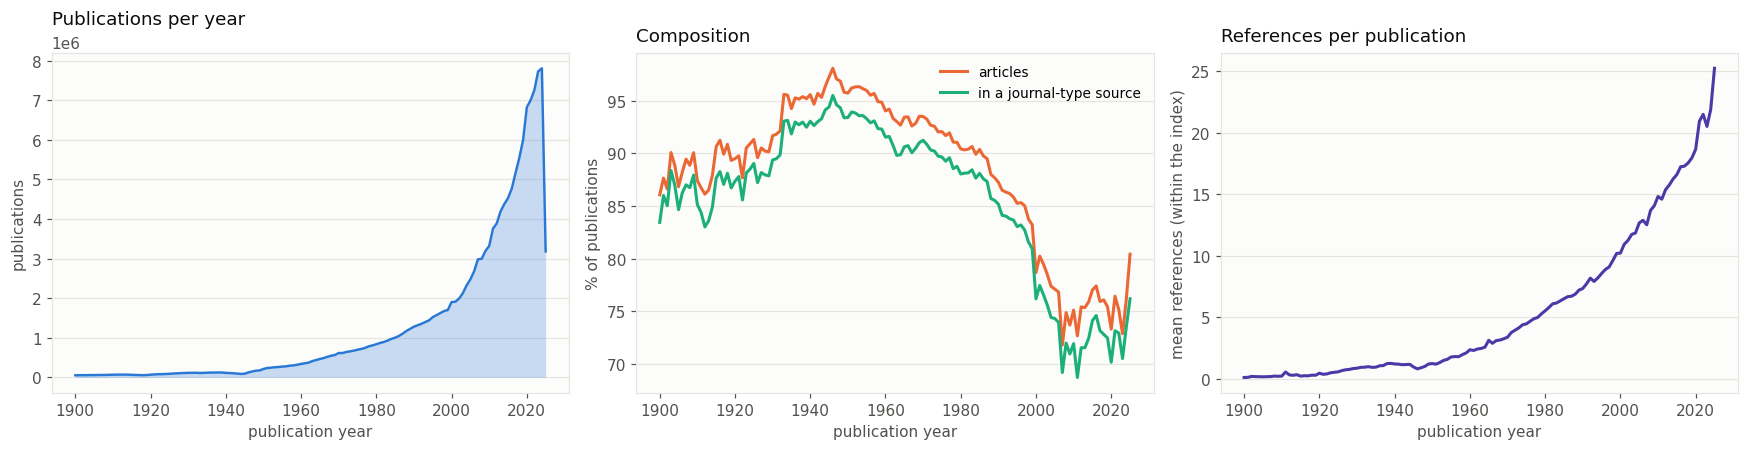

corpus 153,791,737 publications 1900-2025; 25% by 1996; 50% by 2012; 75% by 2020


,doctype,n,pct
0,article,124013142,79.75
1,chapter,15865478,10.20
2,proceeding,8929126,5.74
3,preprint,4673274,3.01
4,monograph,1122724,0.72
5,book,901630,0.58
6,seminar,2620,0.00


,doc_class,n,pct
0,RESEARCH_ARTICLE,73487786,59.26
1,<null>,26768996,21.59
2,OTHER_JOURNAL_CONTENT,8173008,6.59
3,CONFERENCE_ABSTRACT,5046518,4.07
4,REVIEW_ARTICLE,4076850,3.29
5,BOOK_REVIEW,2411134,1.94
6,LETTER_TO_EDITOR,1966450,1.59
7,EDITORIAL,1435315,1.16
8,CORRECTION_ERRATUM,610589,0.49
9,OTHER_CONFERENCE_CONTENT,26057,0.02


CPU times: user 9.05 s, sys: 322 ms, total: 9.38 s
Wall time: 4.95 s


In [3]:
%%time
yr = con.execute(f"""SELECT year, count(*) AS pubs, avg(ref_count) AS mean_refs,
  avg(CASE WHEN doctype = 'article' THEN 1.0 ELSE 0.0 END) AS share_article,
  avg(CASE WHEN is_journal THEN 1.0 ELSE 0.0 END) AS share_journal
  FROM read_parquet('{META}') WHERE year BETWEEN {YEAR_MIN} AND {SNAP} GROUP BY 1 ORDER BY 1""").fetchdf()
types = con.execute(f"SELECT doctype, count(*) AS n FROM read_parquet('{META}') GROUP BY 1 ORDER BY n DESC").fetchdf()
classes = con.execute(f"SELECT coalesce(doc_class, '<null>') AS doc_class, count(*) AS n FROM read_parquet('{META}') WHERE doctype = 'article' GROUP BY 1 ORDER BY n DESC").fetchdf()
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2), layout='constrained')
ax[0].fill_between(yr.year, yr.pubs, color=BLUE, alpha=.25, lw=0); ax[0].plot(yr.year, yr.pubs, lw=1.6, color=BLUE)
style(ax[0], 'publication year', 'publications', 'Publications per year')
ax[1].plot(yr.year, yr.share_article * 100, lw=2, color=ORANGE, label='articles')
ax[1].plot(yr.year, yr.share_journal * 100, lw=2, color=AQUA, label='in a journal-type source')
ax[1].legend(frameon=False, fontsize=9); style(ax[1], 'publication year', '% of publications', 'Composition')
ax[2].plot(yr.year, yr.mean_refs, lw=2, color=VIOLET); style(ax[2], 'publication year', 'mean references (within the index)', 'References per publication')
V.save('2')
print(f'corpus {int(yr.pubs.sum()):,} publications {YEAR_MIN}-{SNAP}; ' + '; '.join(f'{q}% by {int(yr.year[(yr.pubs.cumsum() / yr.pubs.sum() * 100) >= q].iloc[0])}' for q in (25, 50, 75)))
display(types.assign(pct=(types.n / types.n.sum() * 100).round(2)))
display(classes.assign(pct=(classes.n / classes.n.sum() * 100).round(2)).head(10))

## 3. Forward citations — distributions and windowed monotonicity

`C_3 <= C_5 <= C_10 <= C_all` must hold for **every** publication: the windows are nested. It is
asserted rather than eyeballed. Beside it, `C_all` is compared with Dimensions' own
`citations_count` / `metrics.times_cited` carried into `paper_metadata`: ours counts edges present
in the dump, theirs counts citations from the whole index at export time, so ours should be at or
below theirs and correlate almost perfectly.

windowed monotonicity violations: 0


,pubs,never_cited,mean_C_3,mean_C_5,mean_C_10,mean_C_all,max_C_all
0,155441856,71592178,3.739,5.783,9.172,13.759,283270


never cited: 71,592,178 (46.1%)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

C_all (edges in the dump) against Dimensions times_cited (whole index at export):


,n,pearson,pct_ours_le_theirs,mean_ours,mean_theirs
0,155416614,0.999877,99.69,13.761,13.778


/project/jevans/Dawoon/Science of Science/validation/val_common.py:101: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


  [fig] dimension_validation_3.jpg + .pdf  (600 dpi)


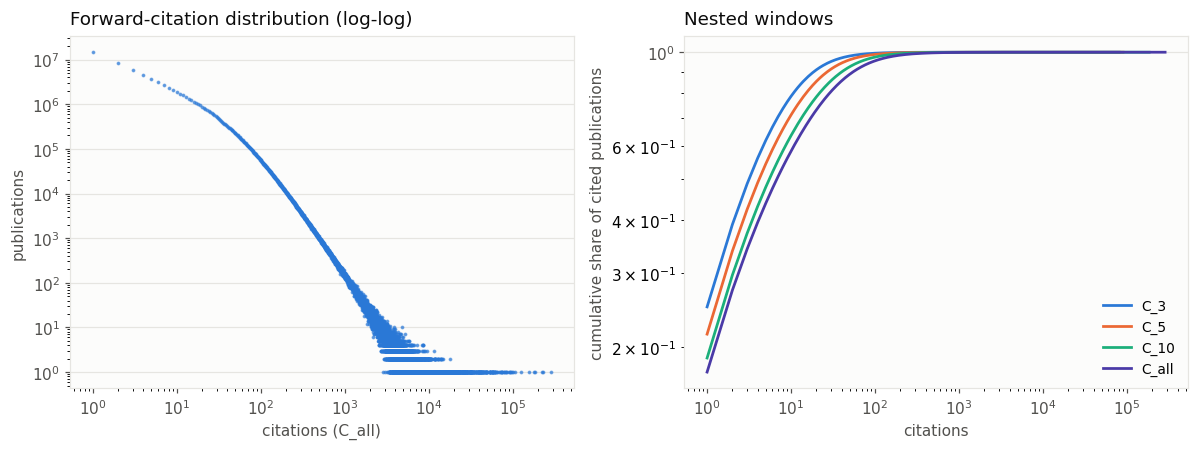

CPU times: user 44.2 s, sys: 4.56 s, total: 48.8 s
Wall time: 11 s


['/project/jevans/Dawoon/Science of Science/validation/Figures/dimension_validation_3.jpg',
 '/project/jevans/Dawoon/Science of Science/validation/Figures/dimension_validation_3.pdf']

In [4]:
%%time
bad = con.execute(f"SELECT count(*) FROM read_parquet('{CIT}') WHERE C_3 > C_5 OR C_5 > C_10 OR C_10 > C_all").fetchone()[0]
print(f'windowed monotonicity violations: {bad:,}')
assert bad == 0, 'C_3 <= C_5 <= C_10 <= C_all is violated -- the citation build is wrong'
st = con.execute(f"""SELECT count(*) AS pubs, count(*) FILTER (WHERE C_all = 0) AS never_cited,
  round(avg(C_3),3) AS mean_C_3, round(avg(C_5),3) AS mean_C_5, round(avg(C_10),3) AS mean_C_10, round(avg(C_all),3) AS mean_C_all,
  max(C_all) AS max_C_all FROM read_parquet('{CIT}')""").fetchdf()
display(st)
print(f"never cited: {int(st.never_cited[0]):,} ({st.never_cited[0] / st.pubs[0] * 100:.1f}%)")
cmp = con.execute(f"""SELECT count(*) AS n, corr(c.C_all, m.cited_by_count) AS pearson,
  round(100.0 * count(*) FILTER (WHERE c.C_all <= m.cited_by_count) / count(*), 2) AS pct_ours_le_theirs,
  round(avg(c.C_all), 3) AS mean_ours, round(avg(m.cited_by_count), 3) AS mean_theirs
  FROM read_parquet('{CIT}') c JOIN read_parquet('{META}') m USING (paper_id) WHERE m.cited_by_count IS NOT NULL""").fetchdf()
print('C_all (edges in the dump) against Dimensions times_cited (whole index at export):'); display(cmp)
d = con.execute(f"SELECT C_all, count(*) AS n FROM read_parquet('{CIT}') WHERE C_all > 0 GROUP BY 1 ORDER BY 1").fetchdf()
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2), layout='constrained')
ax[0].loglog(d.C_all, d.n, '.', ms=3, color=BLUE, alpha=.6); style(ax[0], 'citations (C_all)', 'publications', 'Forward-citation distribution (log-log)')
for w, c in (('C_3', BLUE), ('C_5', ORANGE), ('C_10', AQUA), ('C_all', VIOLET)):
    dd = con.execute(f"SELECT {w} AS v, count(*) AS n FROM read_parquet('{CIT}') WHERE {w} > 0 GROUP BY 1 ORDER BY 1").fetchdf()
    ax[1].loglog(dd.v, dd.n.cumsum() / dd.n.sum(), lw=1.8, color=c, label=w)
style(ax[1], 'citations', 'cumulative share of cited publications', 'Nested windows'); ax[1].legend(frameon=False, fontsize=9)
V.save('3')

## 4. Mean citations by publication year — and the truncation it exposes

The collapse at the right of `C_all` is not a finding: a 2024 paper has had one year to be
cited. Each window is drawn solid only up to `SNAP − w`; `C_all` has no closing year and gets
shorter the nearer a paper sits to the snapshot, so it is the series most damaged by truncation.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

/project/jevans/Dawoon/Science of Science/validation/val_common.py:101: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


  [fig] dimension_validation_4.jpg + .pdf  (600 dpi)


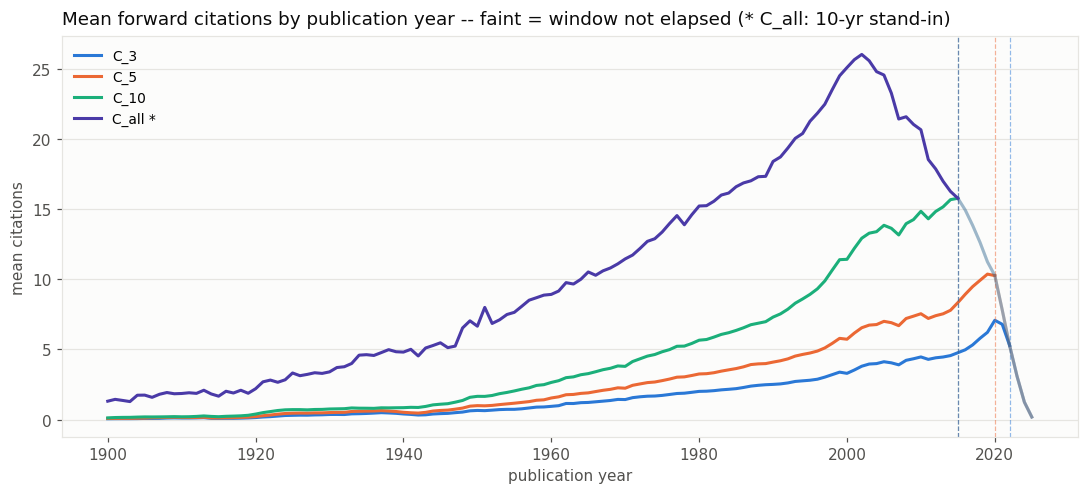

CPU times: user 35 s, sys: 4.36 s, total: 39.4 s
Wall time: 6.11 s


['/project/jevans/Dawoon/Science of Science/validation/Figures/dimension_validation_4.jpg',
 '/project/jevans/Dawoon/Science of Science/validation/Figures/dimension_validation_4.pdf']

In [5]:
%%time
g = con.execute(f"""SELECT m.year, count(*) AS n, avg(c.C_3) AS C_3, avg(c.C_5) AS C_5, avg(c.C_10) AS C_10, avg(c.C_all) AS C_all
  FROM read_parquet('{CIT}') c JOIN read_parquet('{META}') m USING (paper_id)
  WHERE m.year BETWEEN {YEAR_MIN} AND {SNAP} GROUP BY 1 HAVING count(*) >= 1000 ORDER BY 1""").fetchdf()
fig, ax = plt.subplots(figsize=(10, 4.6), layout='constrained')
CLOSE_H = {'C_3': 3, 'C_5': 5, 'C_10': 10, 'C_all': 10}
for col, c in (('C_3', BLUE), ('C_5', ORANGE), ('C_10', AQUA), ('C_all', VIOLET)):
    closed = SNAP - CLOSE_H[col]; s = g[g.year <= closed]; f = g[g.year >= closed]
    ax.plot(s.year, s[col], lw=2, color=c, label=col + (' *' if col == 'C_all' else '')); ax.plot(f.year, f[col], lw=2, color=c, alpha=.28)
    ax.axvline(closed, color=c, lw=.8, ls='--', alpha=.5)
style(ax, 'publication year', 'mean citations', 'Mean forward citations by publication year -- faint = window not elapsed (* C_all: 10-yr stand-in)')
ax.legend(frameon=False, fontsize=9)
V.save('4')

## 5. Citation age profile — when a publication gets cited

From `paper_citation_trend.parquet`, which keeps the full history rather than four windows. The
right panel splits the profile by publication era among cohorts old enough to have the full
range, and the third panel is the patent→paper channel from Dimensions' own patent index.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

/project/jevans/Dawoon/Science of Science/validation/val_common.py:101: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


  [fig] dimension_validation_5.jpg + .pdf  (600 dpi)


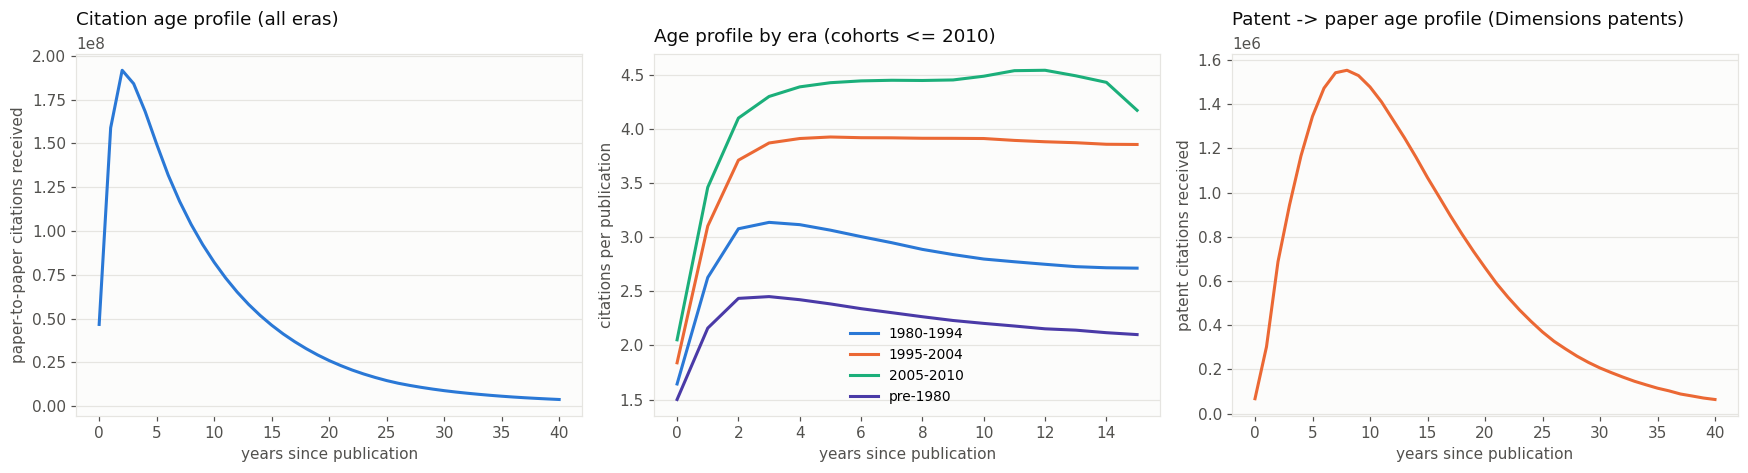

peak paper-to-paper citation age: 2 years; peak patent-to-paper age: 8 years
CPU times: user 2min 27s, sys: 24.2 s, total: 2min 51s
Wall time: 25.3 s


In [6]:
%%time
if not HAS['trd']:
    skip('5', 'paper_citation_trend.parquet')
else:
    age = con.execute(f"SELECT yrs_since_pub AS age, sum(p2p) AS cites, sum(pat2p) AS pat_cites, count(DISTINCT paper_id) AS pubs FROM read_parquet('{TRD}') WHERE yrs_since_pub <= 40 GROUP BY 1 ORDER BY 1").fetchdf()
    era = con.execute(f"""SELECT CASE WHEN pub_year < 1980 THEN 'pre-1980' WHEN pub_year < 1995 THEN '1980-1994' WHEN pub_year < 2005 THEN '1995-2004' ELSE '2005-2010' END AS era,
        yrs_since_pub AS age, sum(p2p)::DOUBLE / count(DISTINCT paper_id) AS per_pub FROM read_parquet('{TRD}')
        WHERE yrs_since_pub <= 15 AND pub_year <= 2010 GROUP BY 1, 2 ORDER BY 1, 2""").fetchdf()
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.4), layout='constrained')
    ax[0].plot(age.age, age.cites, lw=2, color=BLUE); style(ax[0], 'years since publication', 'paper-to-paper citations received', 'Citation age profile (all eras)')
    for (e, gg), c in zip(era.groupby('era'), (BLUE, ORANGE, AQUA, VIOLET)):
        ax[1].plot(gg.age, gg.per_pub, lw=2, color=c, label=e)
    style(ax[1], 'years since publication', 'citations per publication', 'Age profile by era (cohorts <= 2010)'); ax[1].legend(frameon=False, fontsize=9)
    ax[2].plot(age.age, age.pat_cites, lw=2, color=ORANGE); style(ax[2], 'years since publication', 'patent citations received', 'Patent -> paper age profile (Dimensions patents)')
    V.save('5')
    print(f'peak paper-to-paper citation age: {int(age.age[age.cites.idxmax()])} years; peak patent-to-paper age: {int(age.age[age.pat_cites.idxmax()])} years')

## 6. Disruption — CD distribution and the ni / nj / nk composition

CD is bounded in [−1, +1]; the spikes at 0 and ±1 are one-citer arithmetic, not defects, which is
why the distribution is also drawn for publications with at least ten citers. The composition
panel is the diagnostic: a drift in CD is only interesting once you know which term moved.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

/project/jevans/Dawoon/Science of Science/validation/val_common.py:101: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


  [fig] dimension_validation_6.jpg + .pdf  (600 dpi)


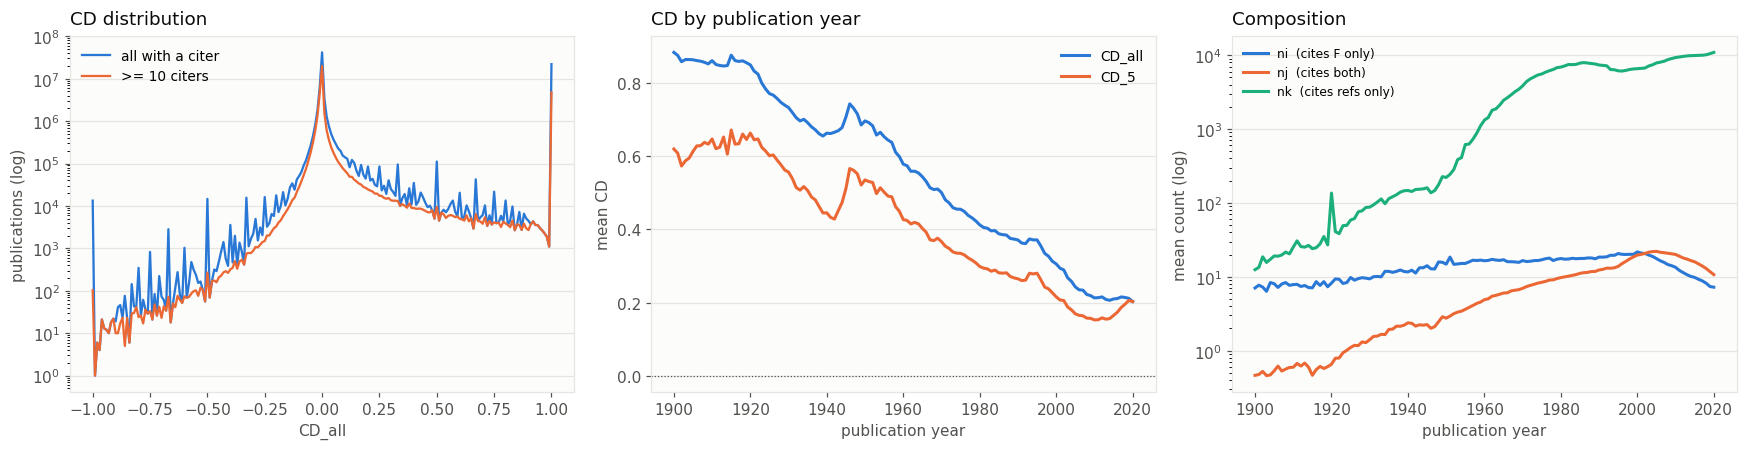

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,mean_CD_all,median_CD_all,pct_plus1,pct_zero,pct_positive
0,0.2695,0.0001,26.29,4.48,51.94


CPU times: user 41.3 s, sys: 6.63 s, total: 48 s
Wall time: 10.6 s


In [7]:
%%time
if not HAS['dis']:
    skip('6', 'paper_disruption.parquet')
else:
    h = con.execute(f"""SELECT round(CD_all, 2) AS cd, count(*) FILTER (WHERE ni_all + nj_all >= 1) AS all_pubs,
        count(*) FILTER (WHERE ni_all + nj_all >= 10) AS cited10 FROM read_parquet('{DIS}') WHERE CD_all IS NOT NULL GROUP BY 1 ORDER BY 1""").fetchdf()
    comp = con.execute(f"""SELECT m.year, count(*) AS n, avg(d.ni_all) AS ni, avg(d.nj_all) AS nj, avg(d.nk_all) AS nk, avg(d.CD_all) AS cd, avg(d.CD_5) AS cd5
        FROM read_parquet('{DIS}') d JOIN read_parquet('{META}') m USING (paper_id)
        WHERE d.CD_all IS NOT NULL AND m.year BETWEEN {YEAR_MIN} AND {SNAP - 5} GROUP BY 1 HAVING count(*) >= 1000 ORDER BY 1""").fetchdf()
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.2), layout='constrained')
    ax[0].semilogy(h.cd, h.all_pubs, lw=1.5, color=BLUE, label='all with a citer'); ax[0].semilogy(h.cd, h.cited10, lw=1.5, color=ORANGE, label='>= 10 citers')
    style(ax[0], 'CD_all', 'publications (log)', 'CD distribution'); ax[0].legend(frameon=False, fontsize=9)
    ax[1].plot(comp.year, comp.cd, lw=2, color=BLUE, label='CD_all'); ax[1].plot(comp.year, comp.cd5, lw=2, color=ORANGE, label='CD_5')
    ax[1].axhline(0, color=MUTED, lw=.8, ls=':'); style(ax[1], 'publication year', 'mean CD', 'CD by publication year'); ax[1].legend(frameon=False, fontsize=9)
    for col, c, lab in (('ni', BLUE, 'ni  (cites F only)'), ('nj', ORANGE, 'nj  (cites both)'), ('nk', AQUA, 'nk  (cites refs only)')):
        ax[2].plot(comp.year, comp[col], lw=2, color=c, label=lab)
    ax[2].set_yscale('log'); style(ax[2], 'publication year', 'mean count (log)', 'Composition'); ax[2].legend(frameon=False, fontsize=8)
    V.save('6')
    display(con.execute(f"""SELECT round(avg(CD_all),4) AS mean_CD_all, round(median(CD_all),4) AS median_CD_all,
        round(100.0*avg(CASE WHEN CD_all = 1 THEN 1 ELSE 0 END),2) AS pct_plus1, round(100.0*avg(CASE WHEN CD_all = 0 THEN 1 ELSE 0 END),2) AS pct_zero,
        round(100.0*avg(CASE WHEN CD_all > 0 THEN 1 ELSE 0 END),2) AS pct_positive FROM read_parquet('{DIS}') WHERE CD_all IS NOT NULL""").fetchdf())

## 7. F / E / G — the citing profile (5-year window)

`F + E + G = 1` for every publication with a citer, asserted. Then the three shares by publication
year as a stacked area, and the share of citers that also cite the focal work's own references.

,defined,not_summing_to_1
0,73168912,0


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

/project/jevans/Dawoon/Science of Science/validation/val_common.py:101: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


  [fig] dimension_validation_7.jpg + .pdf  (600 dpi)


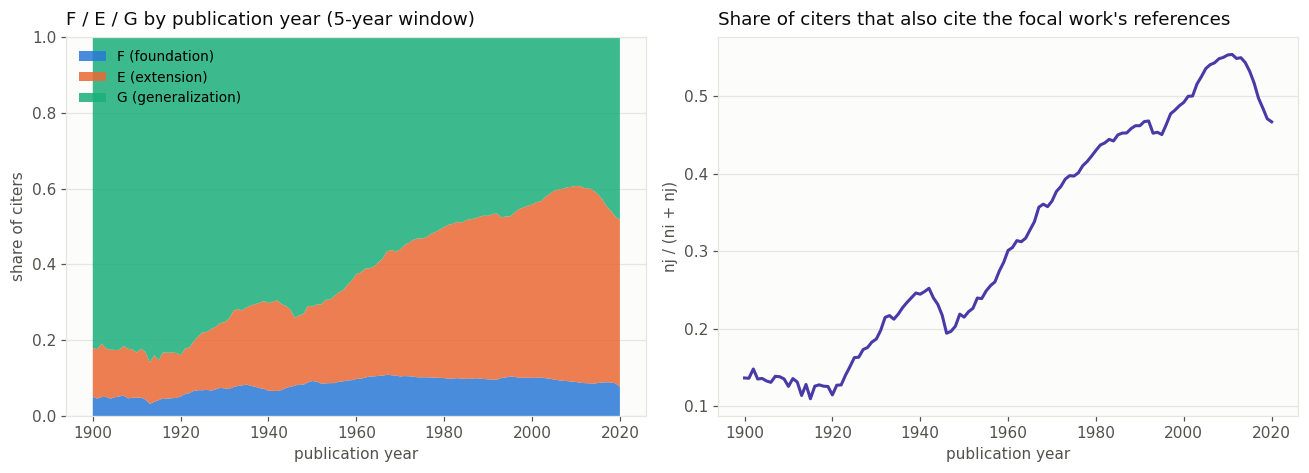

,year,n,F,E,G,njfrac
113,2013,2229350,0.0861,0.5156,0.3984,0.5496
114,2014,2371448,0.0854,0.5098,0.4048,0.5433
115,2015,2501194,0.0869,0.4984,0.4146,0.5321
116,2016,2706093,0.0885,0.4836,0.4280,0.5171
117,2017,2936403,0.0889,0.4647,0.4464,0.4975
118,2018,3176085,0.0884,0.4527,0.4589,0.4845
119,2019,3476097,0.0863,0.4403,0.4735,0.4708
120,2020,3899750,0.0772,0.4404,0.4824,0.4669


CPU times: user 29.8 s, sys: 5.64 s, total: 35.5 s
Wall time: 5.82 s


In [8]:
%%time
if not HAS['dis']:
    skip('7', 'paper_disruption.parquet')
else:
    chk = con.execute(f"SELECT count(*) AS defined, count(*) FILTER (WHERE abs(F_5 + E_5 + G_5 - 1) > 1e-4) AS not_summing_to_1 FROM read_parquet('{DIS}') WHERE F_5 IS NOT NULL").fetchdf()
    display(chk); assert int(chk.not_summing_to_1[0]) == 0, 'F + E + G must be 1 for every defined publication'
    feg = con.execute(f"""SELECT m.year, count(*) AS n, avg(d.F_5) AS F, avg(d.E_5) AS E, avg(d.G_5) AS G,
        avg(d.nj_5 * 1.0 / nullif(d.ni_5 + d.nj_5, 0)) AS njfrac FROM read_parquet('{DIS}') d JOIN read_parquet('{META}') m USING (paper_id)
        WHERE d.F_5 IS NOT NULL AND m.year BETWEEN {YEAR_MIN} AND {SNAP - 5} GROUP BY 1 HAVING count(*) >= 1000 ORDER BY 1""").fetchdf()
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.4), layout='constrained')
    ax[0].stackplot(feg.year, feg.F, feg.E, feg.G, colors=[BLUE, ORANGE, AQUA], labels=['F (foundation)', 'E (extension)', 'G (generalization)'], alpha=.85)
    style(ax[0], 'publication year', 'share of citers', 'F / E / G by publication year (5-year window)'); ax[0].legend(frameon=False, fontsize=9, loc='upper left'); ax[0].set_ylim(0, 1)
    ax[1].plot(feg.year, feg.njfrac, lw=2, color=VIOLET); style(ax[1], 'publication year', 'nj / (ni + nj)', 'Share of citers that also cite the focal work\'s references')
    V.save('7')
    display(feg.tail(8).round(4))

## 8. Hit percentile — and the zero-inflation a percentile cannot hide

`pctl_c*` ranks a publication inside its (FoR division, year) cohort with ties at the lowest rank,
so a large block sits at 0 wherever many are uncited. The distribution is not uniform and should
not be.

/project/jevans/Dawoon/Science of Science/validation/val_common.py:101: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


  [fig] dimension_validation_8.jpg + .pdf  (600 dpi)


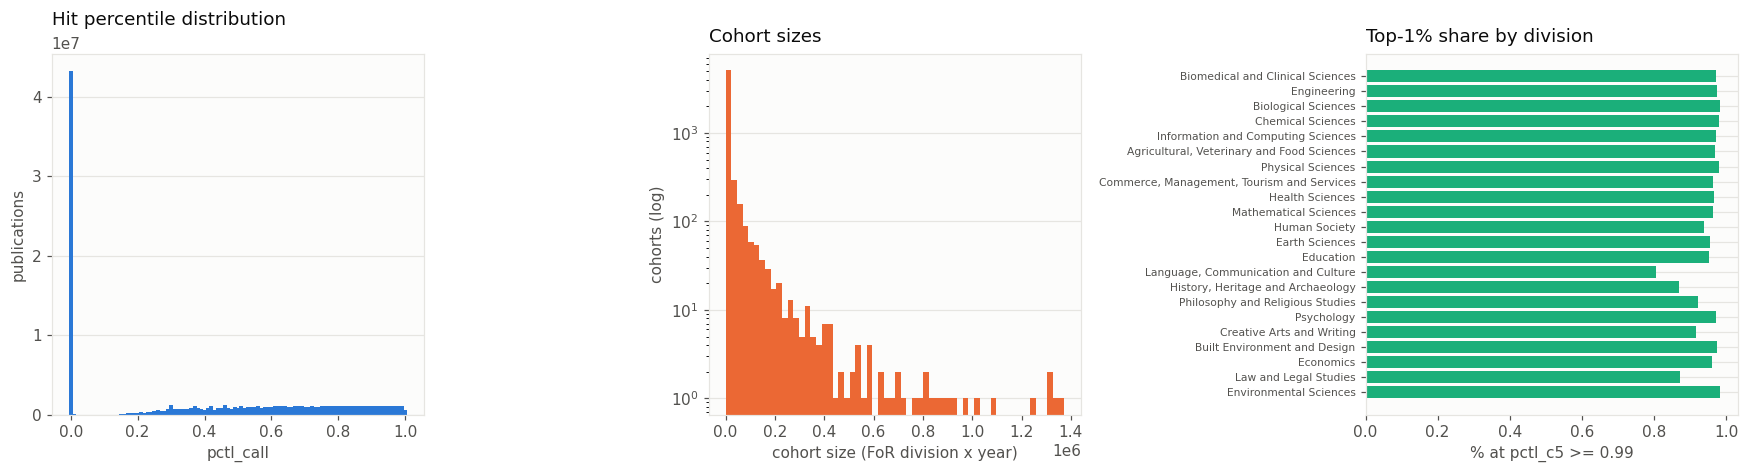

 pct_at_0
      0.0


,FoS,pubs,pct_top1_c5
0,Biomedical and Clinical Sciences,31601815,0.973
1,Engineering,15790078,0.975
2,Biological Sciences,10652532,0.982
3,Chemical Sciences,8595073,0.980
4,Information and Computing Sciences,5833223,0.972
5,"Agricultural, Veterinary and Food Sciences",4744325,0.969
6,Physical Sciences,4538298,0.981
7,"Commerce, Management, Tourism and Services",4273494,0.963
8,Health Sciences,4121427,0.968
9,Mathematical Sciences,4110881,0.965


CPU times: user 7.6 s, sys: 302 ms, total: 7.91 s
Wall time: 4.06 s


In [9]:
%%time
if not HAS['hit']:
    skip('8', 'paper_hit_probability.parquet')
else:
    hp = con.execute(f"SELECT round(pctl_call, 2) AS p, count(*) AS n FROM read_parquet('{HIT}') GROUP BY 1 ORDER BY 1").fetchdf()
    cn = con.execute(f"SELECT FoS, year, count(*) AS cohort_n FROM read_parquet('{HIT}') GROUP BY 1, 2").fetchdf()
    top = con.execute(f"""SELECT FoS, count(*) AS pubs, round(100.0*count(*) FILTER (WHERE pctl_c5 >= 0.99)/count(*), 3) AS pct_top1_c5
        FROM read_parquet('{HIT}') GROUP BY 1 HAVING count(*) >= 20000 ORDER BY pubs DESC""").fetchdf()
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.4), layout='constrained')
    ax[0].bar(hp.p, hp.n, width=.012, color=BLUE); style(ax[0], 'pctl_call', 'publications', 'Hit percentile distribution')
    ax[1].hist(cn.cohort_n, bins=60, color=ORANGE); ax[1].set_yscale('log'); style(ax[1], 'cohort size (FoR division x year)', 'cohorts (log)', 'Cohort sizes')
    ax[2].barh(top.FoS[::-1], top.pct_top1_c5[::-1], color=AQUA); ax[2].tick_params(axis='y', labelsize=7); style(ax[2], '% at pctl_c5 >= 0.99', None, 'Top-1% share by division')
    V.save('8')
    print(con.execute(f"SELECT round(100.0*count(*) FILTER (WHERE pctl_call = 0)/count(*),2) AS pct_at_0 FROM read_parquet('{HIT}')").fetchdf().to_string(index=False))
    display(top)

## 9. By field — does the FoR division behave?

If the division is a useful stratum, metric means should differ across divisions by more than
noise and in ways that make sense. Restricted to divisions with at least 20,000 publications.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,division,pubs,mean_refs,mean_C_all,mean_C_10,mean_CD_all,mean_ni,mean_nj,mean_SB_B
0,Psychology,1798884,26.28,32.01,17.47,0.1632,13.82,17.69,7.495
1,Biological Sciences,10652532,29.01,31.33,20.66,0.1685,12.77,18.10,4.993
2,Chemical Sciences,8595073,25.76,24.96,17.55,0.1640,10.84,13.69,4.448
3,Environmental Sciences,829502,28.69,23.90,17.67,0.1606,11.02,12.40,3.386
4,Earth Sciences,3377353,20.86,20.54,12.49,0.1791,7.89,11.99,5.973
5,Physical Sciences,4538298,18.44,18.60,12.27,0.1102,5.96,11.95,4.288
6,Biomedical and Clinical Sciences,31601815,17.46,18.59,12.75,0.2444,8.26,9.60,4.000
7,Economics,1435351,13.06,16.31,8.84,0.2761,8.75,6.71,7.653
8,"Agricultural, Veterinary and Food Sciences",4744325,19.05,15.76,10.11,0.2363,7.66,7.52,5.455
9,Engineering,15790078,16.63,15.48,11.19,0.1451,7.06,7.83,3.646


/project/jevans/Dawoon/Science of Science/validation/val_common.py:101: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


  [fig] dimension_validation_9.jpg + .pdf  (600 dpi)


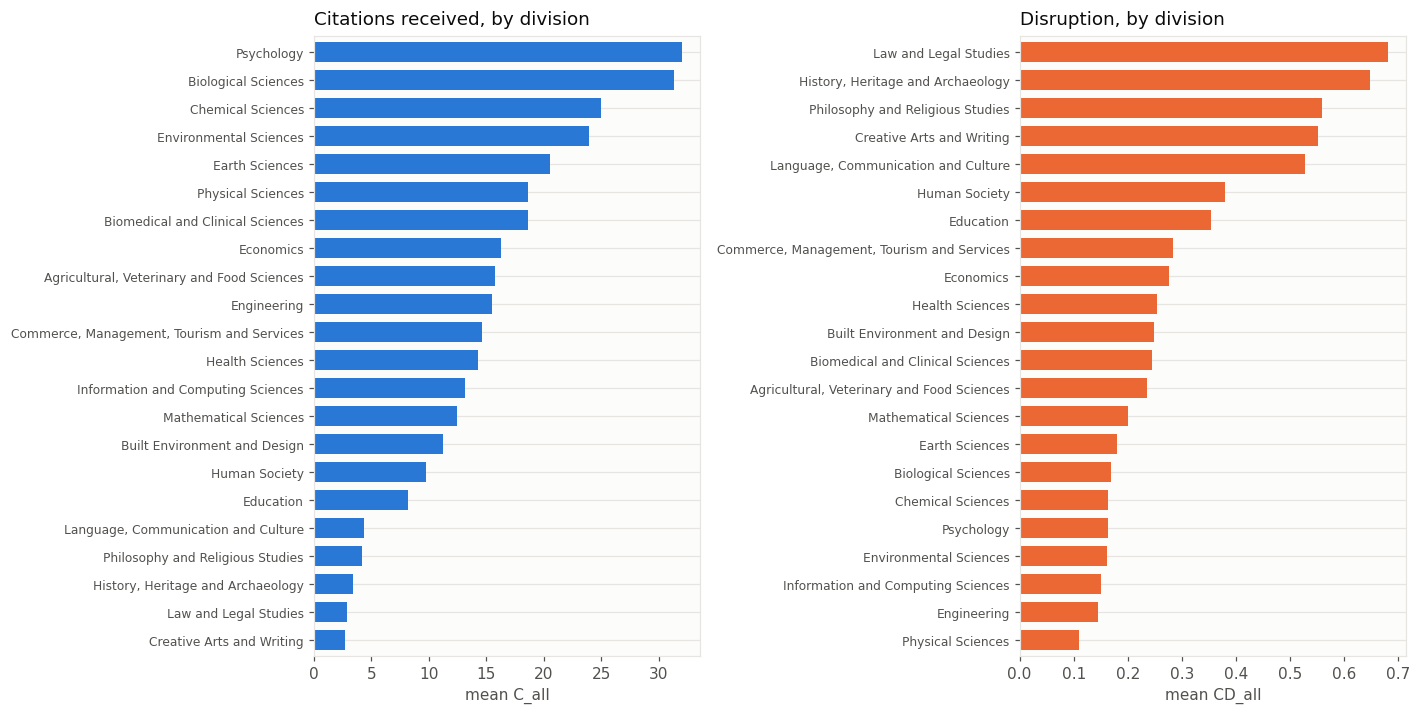

CPU times: user 1min 25s, sys: 18.3 s, total: 1min 44s
Wall time: 16.5 s


['/project/jevans/Dawoon/Science of Science/validation/Figures/dimension_validation_9.jpg',
 '/project/jevans/Dawoon/Science of Science/validation/Figures/dimension_validation_9.pdf']

In [10]:
%%time
extra_join = (f"LEFT JOIN read_parquet('{DIS}') d USING (paper_id)" if HAS['dis'] else '') + (f" LEFT JOIN read_parquet('{SB}') s USING (paper_id)" if HAS['sb'] else '')
extra_cols = (', round(avg(d.CD_all), 4) AS mean_CD_all, round(avg(d.ni_all), 2) AS mean_ni, round(avg(d.nj_all), 2) AS mean_nj' if HAS['dis'] else '') + (', round(avg(s.SB_B), 3) AS mean_SB_B' if HAS['sb'] else '')
byf = con.execute(f"""SELECT m.FoS_rep AS division, count(*) AS pubs, round(avg(m.ref_count), 2) AS mean_refs,
  round(avg(c.C_all), 2) AS mean_C_all, round(avg(c.C_10), 2) AS mean_C_10{extra_cols}
  FROM read_parquet('{META}') m JOIN read_parquet('{CIT}') c USING (paper_id) {extra_join}
  WHERE m.FoS_rep IS NOT NULL GROUP BY 1 HAVING count(*) >= 20000 ORDER BY mean_C_all DESC""").fetchdf()
display(byf)
cols = [('mean_C_all', BLUE, 'mean C_all', 'Citations received, by division')] + ([('mean_CD_all', ORANGE, 'mean CD_all', 'Disruption, by division')] if HAS['dis'] else [])
fig, ax = plt.subplots(1, len(cols), figsize=(6.5 * len(cols), max(4.6, .3 * len(byf))), layout='constrained', squeeze=False)
for a, (col, colour, lab, title) in zip(ax[0], cols):
    o = byf.sort_values(col); a.barh(o.division, o[col], color=colour, height=.72); style(a, lab, None, title); a.tick_params(axis='y', labelsize=8); a.margins(y=.01)
V.save('9')

## 10. Cross-metric correlations

Spearman on a 500k sample. `CD` should relate **negatively** to citation count, `ref_count`
positively to `nj`, and the hit percentile should track `C_all` almost perfectly within cohorts.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  [fig] dimension_validation_10.jpg + .pdf  (600 dpi)


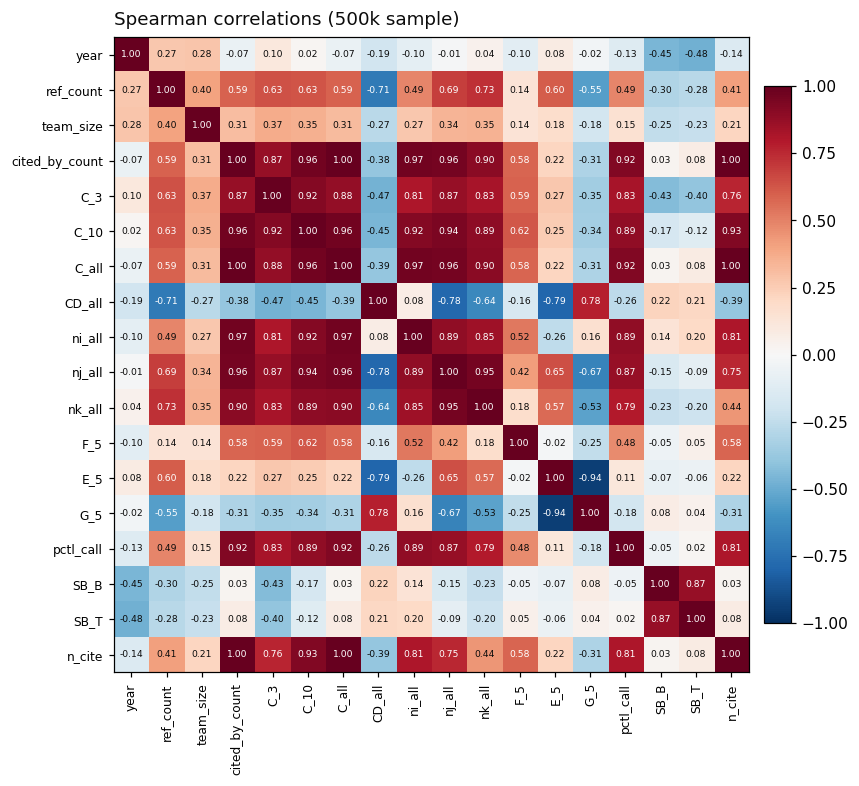

key relationships:
  C_all          vs cited_by_count +0.999
  C_all          vs CD_all         -0.385
  C_all          vs pctl_call      +0.925
  ref_count      vs nj_all         +0.691
  n_cite         vs SB_B           +0.026
  team_size      vs C_all          +0.313
CPU times: user 2min 14s, sys: 27.6 s, total: 2min 42s
Wall time: 41.7 s


In [11]:
%%time
sel = "m.year, m.ref_count, m.team_size, m.cited_by_count, c.C_3, c.C_10, c.C_all"
joins = ''
if HAS['dis']:
    sel += ', d.CD_all, d.ni_all, d.nj_all, d.nk_all, d.F_5, d.E_5, d.G_5'; joins += f" LEFT JOIN read_parquet('{DIS}') d USING (paper_id)"
if HAS['hit']:
    sel += ', h.pctl_call'; joins += f" LEFT JOIN read_parquet('{HIT}') h USING (paper_id)"
if HAS['sb']:
    sel += ', s.SB_B, s.SB_T, s.n_cite'; joins += f" LEFT JOIN read_parquet('{SB}') s USING (paper_id)"
if HAS['zs']:
    sel += ', z.Z_median, z.Z_10pct'; joins += f" LEFT JOIN read_parquet('{ZS}') z USING (paper_id)"
smp = con.execute(f"SELECT {sel} FROM read_parquet('{META}') m JOIN read_parquet('{CIT}') c USING (paper_id) {joins} USING SAMPLE 500000 ROWS").fetchdf()
cr = smp.corr(method='spearman', numeric_only=True)
fig, ax = plt.subplots(figsize=(9, 7.5), layout='constrained')
im = ax.imshow(cr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(cr))); ax.set_xticklabels(cr.columns, rotation=90, fontsize=8); ax.set_yticks(range(len(cr))); ax.set_yticklabels(cr.columns, fontsize=8)
for i in range(len(cr)):
    for j in range(len(cr)):
        v = cr.iloc[i, j]
        if np.isfinite(v):
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6, color='white' if abs(v) > .55 else INK)
ax.set_title('Spearman correlations (500k sample)', color=INK, loc='left', pad=8); fig.colorbar(im, ax=ax, fraction=.035, pad=.02)
V.save('10')
print('key relationships:')
for a, b in (('C_all', 'cited_by_count'), ('C_all', 'CD_all'), ('C_all', 'pctl_call'), ('ref_count', 'nj_all'), ('n_cite', 'SB_B'), ('team_size', 'C_all')):
    if a in cr.index and b in cr.columns:
        print(f'  {a:<14} vs {b:<14} {cr.loc[a, b]:+.3f}')

## 11. Sleeping beauties

`B` is meaningless on a handful of citations, so everything is restricted to `n_cite >= 50`; the
right panel checks that the awakening time of high-`B` publications sits well away from zero.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

9,691,107 publications with >= 50 citations | SB_B median 0.86  p99 150.3  max 38011 | B == 0: 8.2%


/project/jevans/Dawoon/Science of Science/validation/val_common.py:101: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


  [fig] dimension_validation_11.jpg + .pdf  (600 dpi)


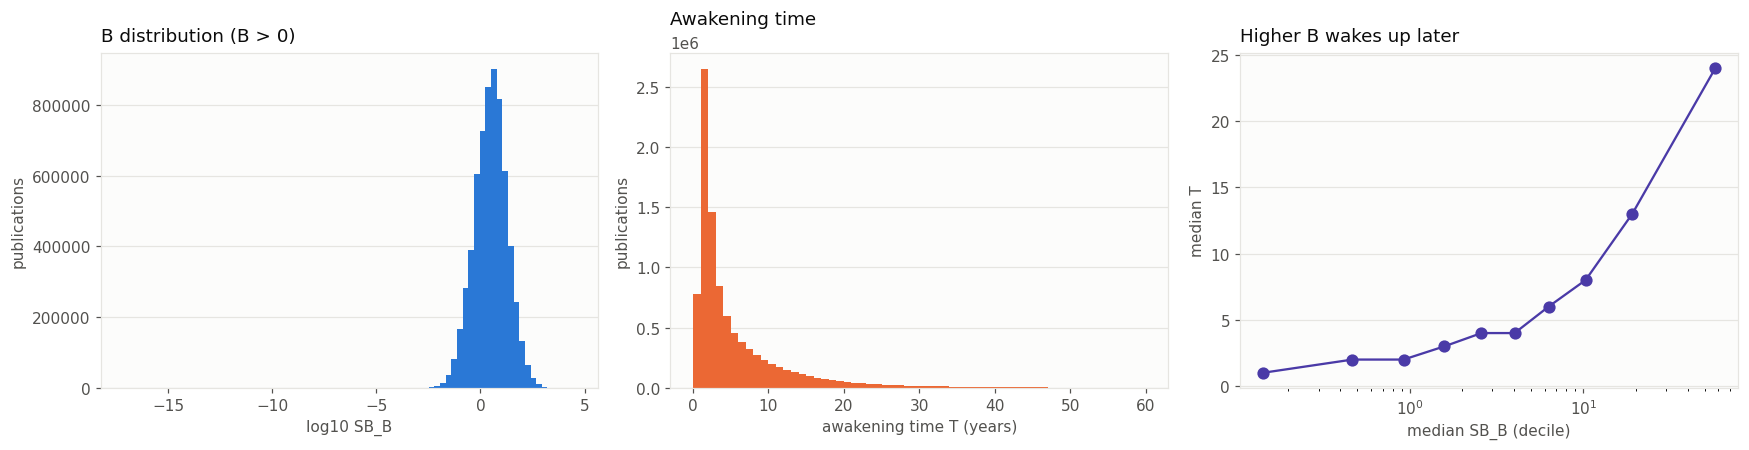

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,paper_id,year,doctype,journal,division,doi,SB_B,SB_T,n_cite
0,pub.1099370191,1758,monograph,,None,10.5962/bhl.title.542,38011.199219,242,3142
1,pub.1087190994,1776,chapter,,None,10.1093/oseo/instance.00043218,35911.601562,206,7814
2,pub.1120238898,1899,chapter,,None,10.1515/9783111582016-025,33379.800781,118,1986
3,pub.1055805656,1958,article,Journal of the American Chemical Society,Chemical Sciences,10.1021/ja01539a017,31320.699219,50,28365
4,pub.1028083705,1805,article,Philosophical Transactions of the Royal,Philosophy and Religious Studies,10.1098/rstl.1805.0005,27283.000000,196,5999
5,pub.1131651734,1937,chapter,,None,10.1525/9780520345089-015,22497.800781,82,1564
6,pub.1090110805,1907,article,Zeitschrift für Physikalische Chemie,Chemical Sciences,10.1515/zpch-1907-5723,21552.500000,96,6185
7,pub.1050450827,1901,article,The London Edinburgh and Dublin Philosop,None,10.1080/14786440109462720,20934.300781,101,9326
8,pub.1154284703,1966,chapter,,None,10.1515/9783112534724-007,19933.800781,55,2868
9,pub.1010033334,1763,article,Philosophical Transactions of the Royal,"Language, Communication and Culture",10.1098/rstl.1763.0053,19237.400391,232,3523


CPU times: user 24.4 s, sys: 5.17 s, total: 29.6 s
Wall time: 8.92 s


In [12]:
%%time
if not HAS['sb']:
    skip('11', 'paper_sb.parquet')
else:
    sb = con.execute(f"SELECT SB_B, SB_T, n_cite FROM read_parquet('{SB}') WHERE n_cite >= 50").fetchdf()
    print(f'{len(sb):,} publications with >= 50 citations | SB_B median {sb.SB_B.median():.2f}  p99 {sb.SB_B.quantile(.99):.1f}  max {sb.SB_B.max():.0f} | B == 0: {(sb.SB_B == 0).mean() * 100:.1f}%')
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.2), layout='constrained')
    pos = sb[sb.SB_B > 0]
    ax[0].hist(np.log10(pos.SB_B), bins=80, color=BLUE); style(ax[0], 'log10 SB_B', 'publications', 'B distribution (B > 0)')
    ax[1].hist(sb.SB_T, bins=range(0, 61), color=ORANGE); style(ax[1], 'awakening time T (years)', 'publications', 'Awakening time')
    q = pd.qcut(pos.SB_B, 10, labels=False, duplicates='drop'); gg = pos.groupby(q).agg(B=('SB_B', 'median'), T=('SB_T', 'median'))
    ax[2].plot(gg['B'], gg['T'], 'o-', color=VIOLET, ms=7); ax[2].set_xscale('log'); style(ax[2], 'median SB_B (decile)', 'median T', 'Higher B wakes up later')
    V.save('11')
    display(con.execute(f"""SELECT s.paper_id, m.year, m.doctype, substr(coalesce(m.journal, ''), 1, 40) AS journal, m.FoS_rep AS division, m.doi,
        round(s.SB_B, 1) AS SB_B, s.SB_T, s.n_cite FROM read_parquet('{SB}') s JOIN read_parquet('{META}') m USING (paper_id)
        WHERE s.n_cite >= 100 ORDER BY s.SB_B DESC LIMIT 12""").fetchdf())

## 12. Atypicality — Z-score CDF and the 2×2 hit probability (Uzzi et al.)

Needs `paper_z_score.parquet` (the merged partitions). The 2×2 splits each axis at the median of
the publication's own year cohort and re-ranks the hit (top 5 % of `C_5`) within division × year
among the publications that have a z-score, so the overall hit rate is 5 % by construction.

In [13]:
%%time
if not (HAS['zs'] and HAS['hit']):
    skip('12', 'paper_z_score.parquet (and paper_hit_probability.parquet)')
else:
    dz = con.execute(f"SELECT Z_median, Z_10pct FROM read_parquet('{ZS}')").fetchdf()
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.4), layout='constrained')
    for col, c in (('Z_10pct', BLUE), ('Z_median', ORANGE)):
        v = np.sort(dz[col].replace([np.inf, -np.inf], np.nan).dropna().to_numpy())
        ax[0].plot(v, np.arange(1, len(v) + 1) / len(v), lw=2, color=c, label=col)
    ax[0].set_xscale('symlog', linthresh=1); ax[0].axvline(0, color=MUTED, lw=.8, ls=':'); style(ax[0], 'Z-score (symlog)', 'CDF of scored publications', 'Atypicality Z-score CDF'); ax[0].legend(frameon=False, fontsize=9)
    d = con.execute(f"""WITH s AS (SELECT h.year, h.FoS, z.Z_median, z.Z_10pct, coalesce(c.C_5, 0) AS C_5 FROM read_parquet('{ZS}') z
            JOIN read_parquet('{HIT}') h USING (paper_id) LEFT JOIN read_parquet('{CIT}') c USING (paper_id) WHERE z.Z_median IS NOT NULL AND z.Z_10pct IS NOT NULL AND h.FoS IS NOT NULL),
        r AS (SELECT year, Z_median, Z_10pct, percent_rank() OVER (PARTITION BY FoS, year ORDER BY C_5) AS cpct FROM s),
        m AS (SELECT year, median(Z_median) AS med_conv_y, median(Z_10pct) AS med_nov_y FROM r GROUP BY year)
        SELECT r.*, m.med_conv_y, m.med_nov_y FROM r JOIN m USING (year)""").fetchdf()
    hi_conv = d.Z_median >= d.med_conv_y; hi_nov = d.Z_10pct <= d.med_nov_y; hit = d.cpct >= .95
    cells = {('LowConv', 'LowNov'): (~hi_conv) & (~hi_nov), ('LowConv', 'HighNov'): (~hi_conv) & hi_nov, ('HighConv', 'LowNov'): hi_conv & (~hi_nov), ('HighConv', 'HighNov'): hi_conv & hi_nov}
    P4 = {k: hit[v].mean() * 100 for k, v in cells.items()}; N4 = {k: int(v.sum()) for k, v in cells.items()}
    lab = ['LowConv\nLowNov', 'LowConv\nHighNov', 'HighConv\nLowNov', 'HighConv\nHighNov']
    ax[1].bar(lab, [P4[k] for k in cells], color=['#c44e52', ORANGE, AQUA, BLUE]); ax[1].axhline(5, color=MUTED, ls=':', lw=1)
    for i, k in enumerate(cells):
        ax[1].text(i, P4[k] + .1, f'{P4[k]:.1f}%\nn={N4[k]:,}', ha='center', fontsize=8)
    style(ax[1], None, 'hit-paper probability (%)', 'Uzzi 2x2: hit = top 5% C_5 within division x year')
    V.save('12')
    print(dz.describe().round(3).to_string())

[12] paper_z_score.parquet (and paper_hit_probability.parquet) is not on disk yet -- the Dimensions chain has not written it; re-run when it has.
CPU times: user 167 μs, sys: 0 ns, total: 167 μs
Wall time: 148 μs


## 13. Authors — team size, resolved authors, countries

`paper_author.parquet` comes straight from the dump's `authors[]`: `team_size` counts every author
slot, `n_resolved` those with a researcher id, `countries` the distinct ISO2 codes over the
affiliation addresses. Team size against disruption and impact is the Wu et al. (2019) figure,
drawn here with the whole team (`team_size`) rather than resolved authors only.

publications with authors: 142,431,518 | mean team size 3.49 | resolved share 77.1% | with a located author 60.7%


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

/project/jevans/Dawoon/Science of Science/validation/val_common.py:101: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


  [fig] dimension_validation_13.jpg + .pdf  (600 dpi)


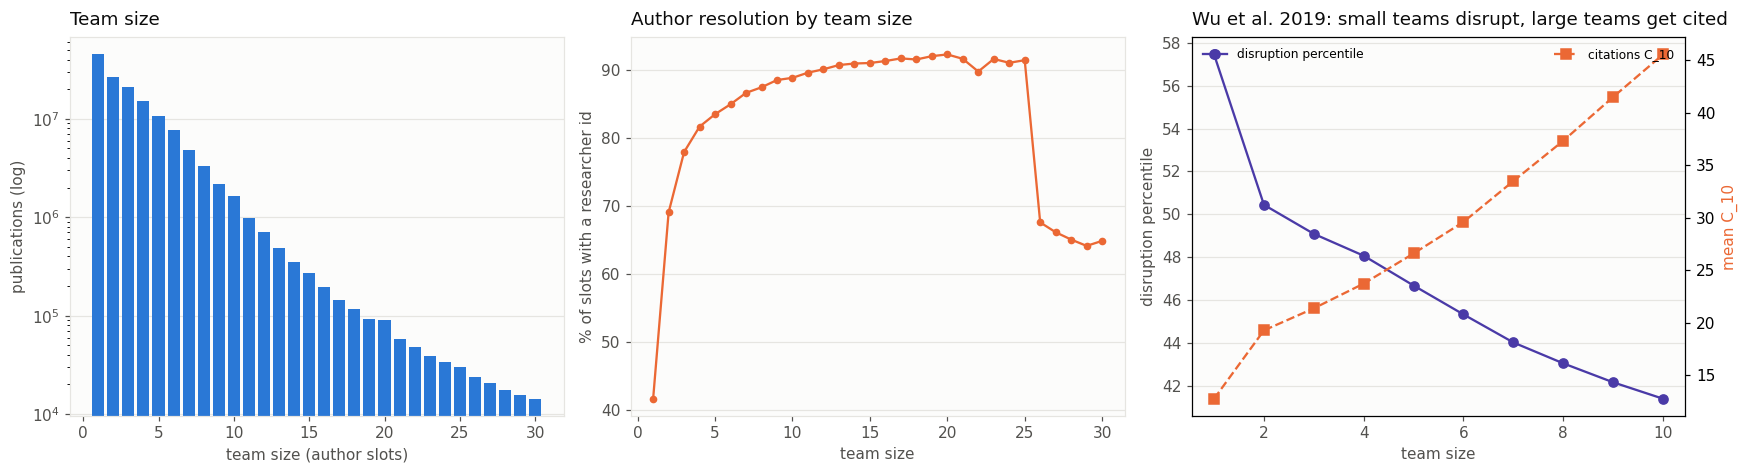

,n_countries,n
0,1,72849041
1,2,10348395
2,3,2122565
3,4,584144
4,5,216710
5,6,100946
6,7,55705
7,8,35939


CPU times: user 1min 1s, sys: 11 s, total: 1min 12s
Wall time: 13.6 s


In [14]:
%%time
ts = con.execute(f"SELECT team_size, count(*) AS n, avg(n_resolved) AS mean_resolved, avg(CASE WHEN countries IS NOT NULL THEN 1.0 ELSE 0.0 END) AS with_country FROM read_parquet('{AU}') GROUP BY 1 ORDER BY 1").fetchdf()
print(f'publications with authors: {int(ts.n.sum()):,} | mean team size {(ts.team_size * ts.n).sum() / ts.n.sum():.2f} | resolved share {(ts.mean_resolved * ts.n).sum() / (ts.team_size * ts.n).sum() * 100:.1f}% | with a located author {(ts.with_country * ts.n).sum() / ts.n.sum() * 100:.1f}%')
fig, ax = plt.subplots(1, 3, figsize=(16, 4.4), layout='constrained')
t = ts[ts.team_size <= 30]; ax[0].bar(t.team_size, t.n, color=BLUE); ax[0].set_yscale('log'); style(ax[0], 'team size (author slots)', 'publications (log)', 'Team size')
ax[1].plot(t.team_size, t.mean_resolved / t.team_size * 100, 'o-', color=ORANGE, ms=4); style(ax[1], 'team size', '% of slots with a researcher id', 'Author resolution by team size')
if HAS['dis']:
    g = con.execute(f"""WITH base AS (SELECT d.CD_all, c.C_10, a.team_size FROM read_parquet('{DIS}') d JOIN read_parquet('{CIT}') c USING (paper_id)
            JOIN read_parquet('{META}') m USING (paper_id) JOIN read_parquet('{AU}') a USING (paper_id)
            WHERE d.CD_all IS NOT NULL AND a.team_size BETWEEN 1 AND 10 AND m.ref_count >= 1 AND m.year BETWEEN 1954 AND 2014),
        ranked AS (SELECT team_size, C_10, percent_rank() OVER (ORDER BY CD_all) AS dpct FROM base)
        SELECT team_size, avg(dpct)*100 AS dis, avg(C_10) AS cit, count(*) AS n FROM ranked GROUP BY 1 ORDER BY 1""").fetchdf()
    ax[2].plot(g.team_size, g.dis, 'o-', color=VIOLET, label='disruption percentile'); ax2 = ax[2].twinx(); ax2.plot(g.team_size, g.cit, 's--', color=ORANGE, label='citations C_10')
    style(ax[2], 'team size', 'disruption percentile', 'Wu et al. 2019: small teams disrupt, large teams get cited'); ax2.set_ylabel('mean C_10', color=ORANGE)
    ax[2].legend(loc='upper left', frameon=False, fontsize=8); ax2.legend(loc='upper right', frameon=False, fontsize=8)
else:
    ax[2].axis('off'); ax[2].text(.5, .5, 'paper_disruption not on disk yet', ha='center', va='center', color=MUTED)
V.save('13')
display(con.execute(f"SELECT n_countries, count(*) AS n FROM read_parquet('{AU}') WHERE countries IS NOT NULL GROUP BY 1 ORDER BY 1 LIMIT 8").fetchdf())

## 14. Dimensions against OpenAlex — the same metrics on the other index

The two pipelines run the same kernels on two indices. Side by side: the corpus size per year,
the forward-citation distribution, the never-cited share, and — where both have written it — the
CD distribution and the beauty coefficient. Differences are properties of the indices (coverage,
reference completeness, document typing), not of the metrics.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

/project/jevans/Dawoon/Science of Science/validation/val_common.py:101: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


  [fig] dimension_validation_14.jpg + .pdf  (600 dpi)


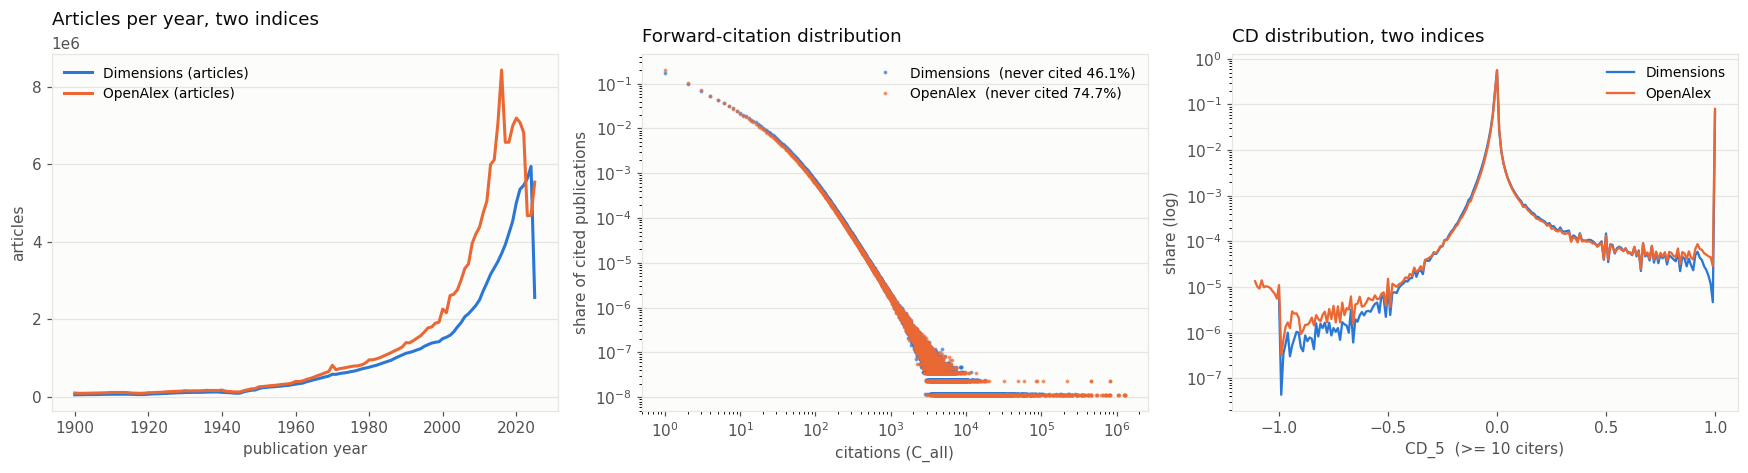

,index,publications,never_cited_pct,mean_C_all,SB_B_median_n50
0,Dimensions,155507994,46.1,13.759,0.865
1,OpenAlex,372655605,74.7,6.175,1.310


done -- re-run after the Dimensions chain finishes to fill the guarded sections
CPU times: user 29.3 s, sys: 1.63 s, total: 30.9 s
Wall time: 16.4 s


In [15]:
%%time
OA_META, OA_CIT, OA_DIS, OA_SB = V.paper('paper_metadata.parquet'), V.paper('paper_citation.parquet'), V.paper('paper_disruption.parquet'), V.paper('paper_sb.parquet')
if not (os.path.exists(OA_META) and os.path.exists(OA_CIT)):
    skip('14', 'OpenAlex/output/paper_metadata + paper_citation')
else:
    yd = con.execute(f"SELECT year, count(*) AS n FROM read_parquet('{META}') WHERE year BETWEEN {YEAR_MIN} AND {SNAP} AND doctype = 'article' GROUP BY 1 ORDER BY 1").fetchdf()
    yo = con.execute(f"SELECT CAST(year AS INTEGER) AS year, count(*) AS n FROM read_parquet('{OA_META}') WHERE year BETWEEN {YEAR_MIN} AND {SNAP} AND doctype = 'article' GROUP BY 1 ORDER BY 1").fetchdf()
    cd_ = con.execute(f"SELECT C_all, count(*) AS n FROM read_parquet('{CIT}') WHERE C_all > 0 GROUP BY 1 ORDER BY 1").fetchdf()
    co_ = con.execute(f"SELECT C_all, count(*) AS n FROM read_parquet('{OA_CIT}') WHERE C_all > 0 GROUP BY 1 ORDER BY 1").fetchdf()
    zd = con.execute(f"SELECT avg(CASE WHEN C_all = 0 THEN 1.0 ELSE 0.0 END) FROM read_parquet('{CIT}')").fetchone()[0]
    zo = con.execute(f"SELECT avg(CASE WHEN C_all = 0 THEN 1.0 ELSE 0.0 END) FROM read_parquet('{OA_CIT}')").fetchone()[0]
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.4), layout='constrained')
    ax[0].plot(yd.year, yd.n, lw=2, color=BLUE, label='Dimensions (articles)'); ax[0].plot(yo.year, yo.n, lw=2, color=ORANGE, label='OpenAlex (articles)')
    style(ax[0], 'publication year', 'articles', 'Articles per year, two indices'); ax[0].legend(frameon=False, fontsize=9)
    ax[1].loglog(cd_.C_all, cd_.n / cd_.n.sum(), '.', ms=3, color=BLUE, alpha=.6, label=f'Dimensions  (never cited {zd * 100:.1f}%)')
    ax[1].loglog(co_.C_all, co_.n / co_.n.sum(), '.', ms=3, color=ORANGE, alpha=.6, label=f'OpenAlex  (never cited {zo * 100:.1f}%)')
    style(ax[1], 'citations (C_all)', 'share of cited publications', 'Forward-citation distribution'); ax[1].legend(frameon=False, fontsize=9)
    if HAS['dis'] and os.path.exists(OA_DIS):
        hd = con.execute(f"SELECT round(CD_5, 2) AS cd, count(*) AS n FROM read_parquet('{DIS}') WHERE CD_5 IS NOT NULL AND ni_5 + nj_5 >= 10 GROUP BY 1 ORDER BY 1").fetchdf()
        ho = con.execute(f"SELECT round(CD_5, 2) AS cd, count(*) AS n FROM read_parquet('{OA_DIS}') WHERE CD_5 IS NOT NULL AND ni_5 + nj_5 >= 10 GROUP BY 1 ORDER BY 1").fetchdf()
        ax[2].semilogy(hd.cd, hd.n / hd.n.sum(), lw=1.5, color=BLUE, label='Dimensions'); ax[2].semilogy(ho.cd, ho.n / ho.n.sum(), lw=1.5, color=ORANGE, label='OpenAlex')
        style(ax[2], 'CD_5  (>= 10 citers)', 'share (log)', 'CD distribution, two indices'); ax[2].legend(frameon=False, fontsize=9)
    else:
        ax[2].axis('off'); ax[2].text(.5, .5, 'disruption not on disk for both indices yet', ha='center', va='center', color=MUTED)
    V.save('14')
    rows = [dict(index='Dimensions', publications=N_CORPUS, never_cited_pct=round(zd * 100, 1), mean_C_all=con.execute(f"SELECT round(avg(C_all), 3) FROM read_parquet('{CIT}')").fetchone()[0]),
            dict(index='OpenAlex', publications=con.execute(f"SELECT count(*) FROM read_parquet('{OA_META}')").fetchone()[0], never_cited_pct=round(zo * 100, 1), mean_C_all=con.execute(f"SELECT round(avg(C_all), 3) FROM read_parquet('{OA_CIT}')").fetchone()[0])]
    if HAS['sb'] and os.path.exists(OA_SB):
        for r, f in zip(rows, (SB, OA_SB)):
            r['SB_B_median_n50'] = con.execute(f"SELECT round(median(SB_B), 3) FROM read_parquet('{f}') WHERE n_cite >= 50").fetchone()[0]
    display(pd.DataFrame(rows))
con.close()
print('done -- re-run after the Dimensions chain finishes to fill the guarded sections')